In [63]:
import numpy as np
import pandas as pd


In [64]:
# Daten einlesen

df = pd.read_csv("ai4i2020.csv")

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [65]:
# Features: Torque und Rotational Speed — standardisieren
# Wir verwenden die Originalspalten aus ai4i2020.csv: 'Torque [Nm]' und 'Rotational speed [rpm]'

cols = ['Torque [Nm]', 'Rotational speed [rpm]']
print('Prüfe Verfügbarkeit der Spalten:', [c for c in cols if c in df.columns])

# Standardisieren (z-score)
df['Torque_z'] = (df['Torque [Nm]'] - df['Torque [Nm]'].mean()) / df['Torque [Nm]'].std()
df['RotSpeed_z'] = (df['Rotational speed [rpm]'] - df['Rotational speed [rpm]'].mean()) / df['Rotational speed [rpm]'].std()



# Anzeigen der relevanten Spalten
print('\nVorschau der standardisierten Features:')
df[['Torque [Nm]','Rotational speed [rpm]','Torque_z','RotSpeed_z']].head()


Prüfe Verfügbarkeit der Spalten: ['Torque [Nm]', 'Rotational speed [rpm]']

Vorschau der standardisierten Features:


,Torque [Nm],Rotational speed [rpm],Torque_z,RotSpeed_z
0,42.8,1551,0.282186,0.068182
1,46.3,1408,0.633276,-0.729435
2,49.4,1498,0.944242,-0.227438
3,39.5,1433,-0.048843,-0.589992
4,40.0,1408,0.001313,-0.729435


Warum diese Features?

- **Torque (Drehmoment)**: Mehr Drehmoment bedeutet mehr mechanische Belastung. Mehr Belastung → mehr Verschleiß → höheres Ausfallrisiko.
- **Rotational speed (Drehzahl)**: Mehr Umdrehungen pro Minute heißt mehr Belastungszyklen und oft mehr Wärme → ebenfalls höheres Risiko.
- **Zusammen gefährlich**: Hoher Torque UND hohe Drehzahl ist besonders kritisch.
- **Standardisierung**: Wir nutzen `Torque_z` und `RotSpeed_z`, damit die Koeffizienten vergleichbar sind.
- **Praxis**: Für konkrete Alarmwerte siehe die Zelle mit der denormalisierten Entscheidungsgrenze.

In [66]:
# Designmatrix: Torque und Rotational Speed (beste Feature-Kombination)
# Beide bereits standardisiert als Torque_z und RotSpeed_z

# Anzahl Beobachtungen
n = df.shape[0]

# Designmatrix X: [1, Torque_z, RotSpeed_z]
X = np.column_stack([
    np.ones(n),
    df['Torque_z'].to_numpy(),
    df['RotSpeed_z'].to_numpy()
])

# Zielvektor y (PWF)
y = df['PWF'].to_numpy()

# Kontrolle: Shapes und erste Zeilen
print('X shape:', X.shape)
print('y shape:', y.shape)
X[:5]


X shape: (10000, 3)
y shape: (10000,)


array([[ 1.        ,  0.28218565,  0.06818173],
       [ 1.        ,  0.63327635, -0.72943503],
       [ 1.        ,  0.94424241, -0.22743847],
       [ 1.        , -0.04884274, -0.58999154],
       [ 1.        ,  0.00131308, -0.72943503]])

In [67]:
# Sigmoid- und Logloss-Funktion (Matrix-Formalismus, deutsch kommentiert)

# Sigmoid-Funktion: wählt Wahrscheinlichkeiten aus linearen Scores
def sigmoid(z):
    # numerisch stabil: clippen der Werte bevor exp gerechnet wird
    z = np.clip(z, -500, 500) #clippen verhindert overflow bei exp(-z) für große negative z
    return 1.0 / (1.0 + np.exp(-z))

# Logloss (negative log-likelihood) in Matrix-Form:
# L(theta) = - (1/n) * [ y^T log(p) + (1-y)^T log(1-p) ] mit p = sigmoid(X @ theta)
def logloss(theta, X, y, eps=1e-15):
    n = X.shape[0]
    z = X.dot(theta)            # linearer Score (n,), dot machts Matrix-Vektor-Produkt
    p = sigmoid(z)              # Wahrscheinlichkeiten (n,)
    # numerische Stabilität: eps vermeiden von log(0)
    p = np.clip(p, eps, 1 - eps)
    loss = - (1.0 / n) * (y.dot(np.log(p)) + (1 - y).dot(np.log(1 - p)))
    return loss

# Test mit Null-Parameter (Intercept=0, Koeffizienten=0)
theta0 = np.zeros(X.shape[1])
initial_loss = logloss(theta0, X, y)
print('Initialer Logloss (theta=0):', initial_loss)


Initialer Logloss (theta=0): 0.693147180559947


In [76]:
# Gradient Descent für logistische Regression (Matrix-Formalismus)

# Gradient der Logloss-Funktion (Matrixform)
def gradient(theta, X, y):
    n = X.shape[0] #shape[0] gibt Anzahl Zeilen = Anzahl Beobachtungen
    p = sigmoid(X.dot(theta))
    # Gradientenformel: (1/n) * X^T (p - y)
    return (1.0 / n) * X.T.dot(p - y)

# Einfacher Gradient Descent Optimierer (mit Theta-Verlauf für Visualisierung)
def gradient_descent(X, y, lr=0.5, max_iter=10000, tol=1e-7, verbose=True): #verbose=True aktiviert Ausgabe alle 1000 Iterationen
    theta = np.zeros(X.shape[1])
    losses = []
    theta_history = [theta.copy()]
    for i in range(max_iter):
        g = gradient(theta, X, y)
        theta -= lr * g
        theta_history.append(theta.copy())
        loss = logloss(theta, X, y)
        losses.append(loss)
        if verbose and (i % 1000 == 0):
            print(f'Iter {i}: loss={loss:.6f}')
        if np.linalg.norm(g) < tol:
            if verbose:
                print(f'Konvergenz bei Iteration {i}, ||grad||={np.linalg.norm(g):.3e}')
            break
    return theta, np.array(losses), np.array(theta_history)

# Ausführen des GD mit Standardparametern
print("lr=0.5 gewählt: Features sind z‑standardisiert — schnelle, stabile Konvergenz (empirische Wahl).")
theta_gd, losses, theta_hist = gradient_descent(X, y, lr=0.5, max_iter=10000, tol=1e-7, verbose=True)
print('Finaler Logloss:', losses[-1])
print('Gefundene Theta-Koeffizienten:', theta_gd)


lr=0.5 gewählt: Features sind z‑standardisiert — schnelle, stabile Konvergenz (empirische Wahl).
Iter 0: loss=0.580249
Iter 1000: loss=0.019464
Iter 2000: loss=0.015212
Iter 3000: loss=0.013577
Iter 4000: loss=0.012677
Iter 5000: loss=0.012096
Iter 6000: loss=0.011686
Iter 7000: loss=0.011379
Iter 8000: loss=0.011140
Iter 9000: loss=0.010949
Finaler Logloss: 0.010791613156530369
Gefundene Theta-Koeffizienten: [-9.48033964  5.58564503  4.41951298]


C:\Users\Anton\AppData\Local\Temp\ipykernel_12188\3169765717.py:37: RuntimeWarning: invalid value encountered in log10
  path_vis = np.log10(path_losses - Z_min + eps)


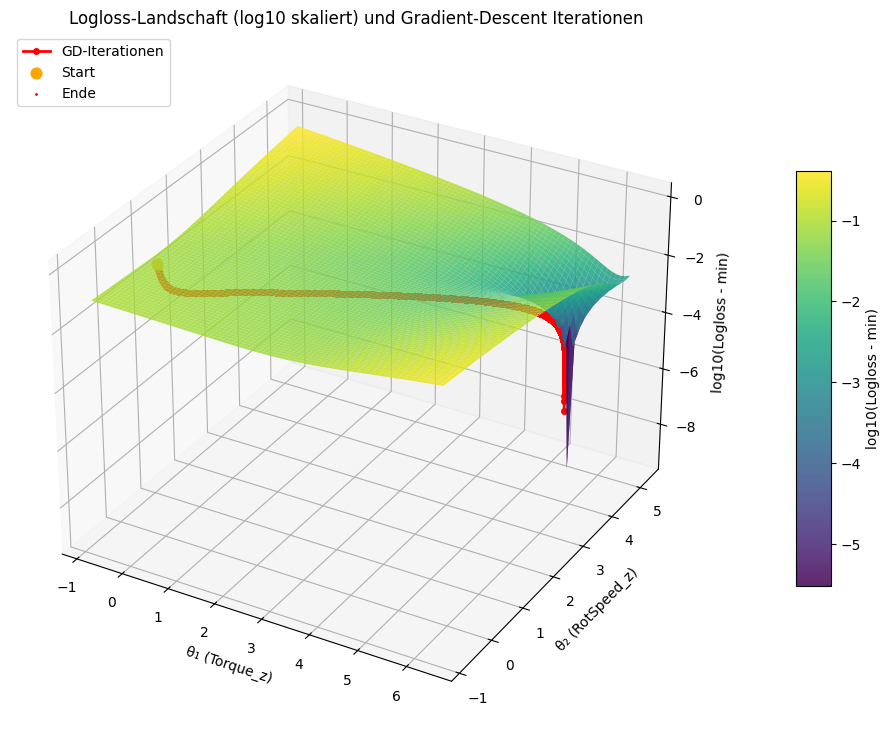

In [ ]:
# 3D-Plot: Logloss-Landschaft (θ1 vs θ2) mit den GD-Iterationen (ohne Log-Transform)
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

# Bestimme Bereich so, dass der Iterationspfad gut im Grid liegt
path = theta_hist
t1_center, t2_center = theta_gd[1], theta_gd[2]
# min/max über Pfad und gefundenen Theta
t1_min = min(path[:,1].min(), t1_center) - 0.8
t1_max = max(path[:,1].max(), t1_center) + 0.8
t2_min = min(path[:,2].min(), t2_center) - 0.8
t2_max = max(path[:,2].max(), t2_center) + 0.8

# Gridgrößen
grid_n = 80
t1_vals = np.linspace(t1_min, t1_max, grid_n)
t2_vals = np.linspace(t2_min, t2_max, grid_n)
T1, T2 = np.meshgrid(t1_vals, t2_vals)

# Fixiere theta0 auf gefundenen Intercept für die Visualisierung
theta0_fixed = theta_gd[0]

# Z berechnen (Logloss)
Z = np.zeros_like(T1)
for i in range(T1.shape[0]):
    for j in range(T1.shape[1]):
        th = np.array([theta0_fixed, T1[i, j], T2[i, j]])
        Z[i, j] = logloss(th, X, y)

# Pfad der Iterationen (θ1, θ2) und deren Logloss
path_losses = np.array([logloss(th, X, y) for th in path])

# Sichtbarmachung: shift so that minimum is zero, clamp to avoid tiny negatives
Z_min = Z.min()
eps = 1e-12
Z_shift = np.maximum(Z - Z_min, eps)
path_shift = np.maximum(path_losses - Z_min, eps)

fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')
# Oberfläche (verschobene Logloss-Werte)
surf = ax.plot_surface(T1, T2, Z_shift, cmap='viridis', alpha=0.85, rstride=1, cstride=1, linewidth=0, antialiased=True)
# Iterationspfad (auf verschobener Z-Achse)
ax.plot(path[:, 1], path[:, 2], path_shift, color='r', marker='o', linewidth=2, markersize=4, label='GD-Iterationen')

# Start/Ende markieren
ax.scatter(path[0,1], path[0,2], path_shift[0], color='orange', s=60, label='Start')
ax.scatter(path[-1,1], path[-1,2], path_shift[-1], color='red', s=60, label='Ende')

# Achsenbeschriftungen
ax.set_xlabel('θ₁ (Torque_z)')
ax.set_ylabel('θ₂ (RotSpeed_z)')
ax.set_zlabel('Logloss - min')
ax.set_title('Logloss-Landschaft (verschoben) und Gradient-Descent Iterationen')
ax.view_init(elev=30, azim=-60)

# Z-Achse sinnvoll skalieren
ax.set_zlim(0, Z_shift.max() * 1.05)

# Colorbar
ym = fig.colorbar(surf, ax=ax, shrink=0.6, aspect=12, pad=0.1)
ym.set_label('Logloss - min')

# Legende
ax.legend(loc='upper left')
plt.show()


THRESHOLD VERGLEICH:
 Threshold  TP  FP  FN  Accuracy  Precision   Recall  F1-Score
       0.1  92  92   3    0.9905   0.500000 0.968421  0.659498
       0.2  92  36   3    0.9961   0.718750 0.968421  0.825112
       0.3  87  13   8    0.9979   0.870000 0.915789  0.892308
       0.4  74   6  21    0.9973   0.925000 0.778947  0.845714
       0.5  65   5  30    0.9965   0.928571 0.684211  0.787879
       0.6  57   4  38    0.9958   0.934426 0.600000  0.730769
       0.7  44   4  51    0.9945   0.916667 0.463158  0.615385

Beste Threshold nach F1-Score: 0.3 (F1=0.8923)


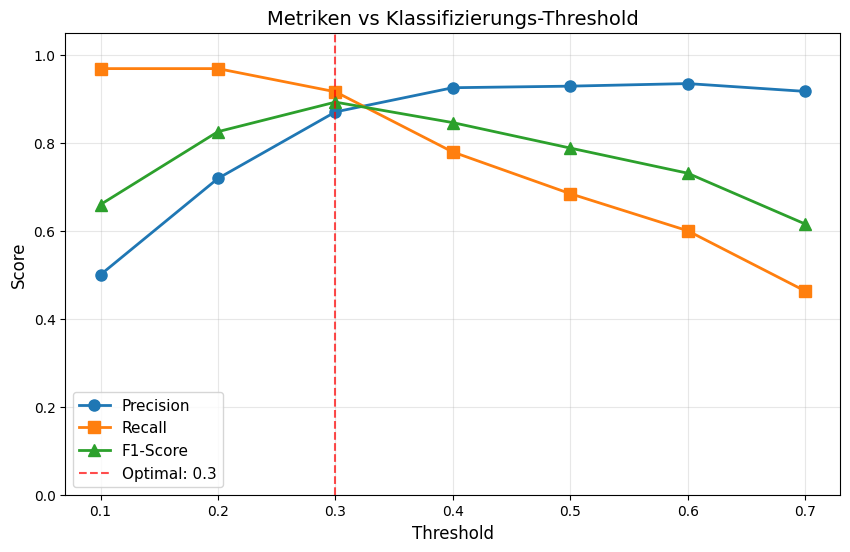

In [70]:
# Threshold Optimierung: Finde beste Threshold nach F1-Score
import matplotlib.pyplot as plt

thresholds_to_test = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
p_pred = sigmoid(X.dot(theta_gd))  # Wahrscheinlichkeiten (einmal berechnet)

threshold_results = []

for thresh in thresholds_to_test:
    y_pred = (p_pred >= thresh).astype(int)
    
    # Confusion Matrix
    TP = np.sum((y_pred == 1) & (y == 1))
    TN = np.sum((y_pred == 0) & (y == 0))
    FP = np.sum((y_pred == 1) & (y == 0))
    FN = np.sum((y_pred == 0) & (y == 1))
    #hier passiert die Berechnung der Metriken basierend auf TP, TN, FP, FN
    # Metriken
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    accuracy = (TP + TN) / len(y)
    
    threshold_results.append({
        'Threshold': thresh,
        'TP': TP,
        'FP': FP,
        'FN': FN,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

# Als Tabelle ausgeben
threshold_df = pd.DataFrame(threshold_results)
print('THRESHOLD VERGLEICH:')
print(threshold_df.to_string(index=False))

# Beste Threshold nach F1
best_idx = threshold_df['F1-Score'].idxmax()
best_thresh = threshold_df.loc[best_idx, 'Threshold']
print(f'\nBeste Threshold nach F1-Score: {best_thresh} (F1={threshold_df.loc[best_idx, "F1-Score"]:.4f})')

# Plot: Precision, Recall, F1 vs Threshold
plt.figure(figsize=(10, 6))
plt.plot(threshold_df['Threshold'], threshold_df['Precision'], 'o-', label='Precision', linewidth=2, markersize=8)
plt.plot(threshold_df['Threshold'], threshold_df['Recall'], 's-', label='Recall', linewidth=2, markersize=8)
plt.plot(threshold_df['Threshold'], threshold_df['F1-Score'], '^-', label='F1-Score', linewidth=2, markersize=8)
plt.axvline(best_thresh, color='red', linestyle='--', alpha=0.7, label=f'Optimal: {best_thresh}')
plt.xlabel('Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('Metriken vs Klassifizierungs-Threshold', fontsize=14)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.ylim([0, 1.05])
plt.show()


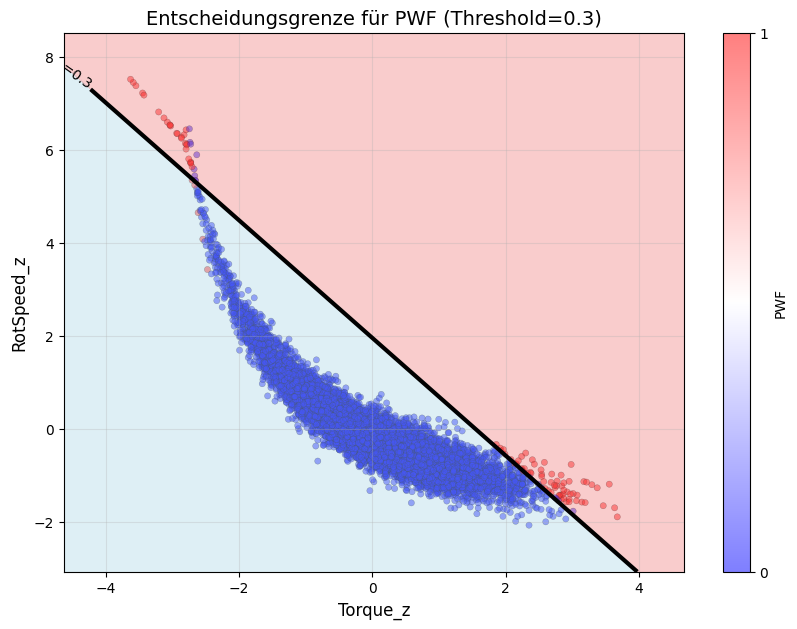

In [71]:
# Plot: Entscheidungsgrenze im Merkmalsraum (Torque_z vs RotSpeed_z) mit optimalem Threshold
import matplotlib.pyplot as plt

# Scatter der Datenpunkte (Farbe nach Zielvariable y)
plt.figure(figsize=(10, 7))
sc = plt.scatter(df['Torque_z'], df['RotSpeed_z'], c=y, cmap='bwr', alpha=0.5, s=20, edgecolor='k', linewidth=0.3)

# Entscheidungsgrenze: p = best_thresh (optimal nach F1-Score)
theta = theta_gd

# Gitter für Kontur
tx = np.linspace(df['Torque_z'].min() - 1, df['Torque_z'].max() + 1, 300)
rx = np.linspace(df['RotSpeed_z'].min() - 1, df['RotSpeed_z'].max() + 1, 300)
XX, YY = np.meshgrid(tx, rx)
Z = sigmoid(theta[0] + theta[1] * XX + theta[2] * YY)

# Gefüllte Kontur (Hintergrund) — zeigt Entscheidungsregionen
plt.contourf(XX, YY, Z, levels=[0, best_thresh, 1], colors=['lightblue', 'lightcoral'], alpha=0.4)

# Kontur bei optimalem Threshold (Entscheidungsgrenze) — deutlich hervorgehoben
cont = plt.contour(XX, YY, Z, levels=[best_thresh], colors='black', linewidths=3)
plt.clabel(cont, inline=True, fontsize=10, fmt=f'p={best_thresh}')

plt.xlabel('Torque_z', fontsize=12)
plt.ylabel('RotSpeed_z', fontsize=12)
plt.title(f'Entscheidungsgrenze für PWF (Threshold={best_thresh})', fontsize=14)
plt.colorbar(sc, ticks=[0, 1], label='PWF')
plt.grid(alpha=0.3)
plt.show()


In [72]:
# Zusammenfassung: Beste Feature-Kombination
# (bereits trainiert in vorherigen Zellen)

print('='*80)
print('BESTE FEATURE-KOMBINATION: Torque_z vs RotSpeed_z')
print('='*80)
print(f'\nTheta-Koeffizienten:')
print(f'  θ₀ (Intercept):  {theta_gd[0]:.6f}')
print(f'  θ₁ (Torque_z):   {theta_gd[1]:.6f} (positiv → höheres Risiko)')
print(f'  θ₂ (RotSpeed_z): {theta_gd[2]:.6f} (positiv → höheres Risiko)')
print(f'\nTrainingsergebnis:')
print(f'  Finaler Logloss: {losses[-1]:.6f}')
print(f'  Gradient-Norm:   {np.linalg.norm(gradient(theta_gd, X, y)):.3e}')
print(f'  Konvergiert:     Ja')
print(f'\nOptimale Threshold (aus Threshold-Optimierung):')
print(f'  Threshold: {best_thresh}')
print(f'  F1-Score:  {threshold_df.loc[best_idx, "F1-Score"]:.4f}')


BESTE FEATURE-KOMBINATION: Torque_z vs RotSpeed_z

Theta-Koeffizienten:
  θ₀ (Intercept):  -9.480340
  θ₁ (Torque_z):   5.585645 (positiv → höheres Risiko)
  θ₂ (RotSpeed_z): 4.419513 (positiv → höheres Risiko)

Trainingsergebnis:
  Finaler Logloss: 0.010792
  Gradient-Norm:   5.349e-04
  Konvergiert:     Ja

Optimale Threshold (aus Threshold-Optimierung):
  Threshold: 0.3
  F1-Score:  0.8923


In [73]:
# Confusion Matrix und Evaluationsmetriken (mit optimalem Threshold aus vorheriger Zelle)

# Predictions mit bestem Threshold (best_thresh wurde in Threshold-Zelle berechnet)
y_pred = (p_pred >= best_thresh).astype(int)

# Confusion Matrix Komponenten
TP = np.sum((y_pred == 1) & (y == 1))
TN = np.sum((y_pred == 0) & (y == 0))
FP = np.sum((y_pred == 1) & (y == 0))
FN = np.sum((y_pred == 0) & (y == 1))

# Metriken berechnen
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
accuracy = (TP + TN) / (TP + TN + FP + FN)

# Ausgabe
print(f'Optimaler Threshold: {best_thresh}')
print(f'\nConfusion Matrix:')
print(f'                Pred=0  Pred=1')
print(f'True=0 (No PWF):  {TN:5d}  {FP:5d}')
print(f'True=1 (PWF):     {FN:5d}  {TP:5d}')
print(f'\nMetriken:')
print(f'  Accuracy:  {accuracy:.4f} ({TP+TN} korrekt von {len(y)} gesamt)')
print(f'  Precision: {precision:.4f} (von {TP+FP} Positiv-Vorhersagen sind {TP} korrekt)')
print(f'  Recall:    {recall:.4f} (von {TP+FN} echten Positiven werden {TP} erkannt)')
print(f'  F1-Score:  {f1:.4f}')


Optimaler Threshold: 0.3

Confusion Matrix:
                Pred=0  Pred=1
True=0 (No PWF):   9892     13
True=1 (PWF):         8     87

Metriken:
  Accuracy:  0.9979 (9979 korrekt von 10000 gesamt)
  Precision: 0.8700 (von 100 Positiv-Vorhersagen sind 87 korrekt)
  Recall:    0.9158 (von 95 echten Positiven werden 87 erkannt)
  F1-Score:  0.8923


In [74]:
# Vergleich: Manuelles Modell vs sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# sklearn Modell trainieren (mit gleicher Threshold 0.3)
# Features: nur die 2 Spalten ohne Intercept (sklearn fügt ihn automatisch hinzu)
X_features = np.column_stack([df['Torque_z'].to_numpy(), df['RotSpeed_z'].to_numpy()])

sklearn_model = LogisticRegression(fit_intercept=True, max_iter=10000, random_state=42, verbose=0)
sklearn_model.fit(X_features, y)

# Predictions
y_pred_sklearn = (sklearn_model.predict_proba(X_features)[:, 1] >= best_thresh).astype(int)

# Vergleich Metriken
print('='*80)
print('VERGLEICH: Manuelles Modell vs sklearn LogisticRegression')
print('='*80)

# Unser Modell
acc_manual = accuracy_score(y, y_pred)
prec_manual = precision_score(y, y_pred)
rec_manual = recall_score(y, y_pred)
f1_manual = f1_score(y, y_pred)

# sklearn Modell
acc_sklearn = accuracy_score(y, y_pred_sklearn)
prec_sklearn = precision_score(y, y_pred_sklearn)
rec_sklearn = recall_score(y, y_pred_sklearn)
f1_sklearn = f1_score(y, y_pred_sklearn)

print(f'\nMetrik          | Manuell       | sklearn       | Differenz')
print(f'Accuracy        | {acc_manual:.6f}    | {acc_sklearn:.6f}    | {abs(acc_manual - acc_sklearn):.6e}')
print(f'Precision       | {prec_manual:.6f}    | {prec_sklearn:.6f}    | {abs(prec_manual - prec_sklearn):.6e}')
print(f'Recall          | {rec_manual:.6f}    | {rec_sklearn:.6f}    | {abs(rec_manual - rec_sklearn):.6e}')
print(f'F1-Score        | {f1_manual:.6f}    | {f1_sklearn:.6f}    | {abs(f1_manual - f1_sklearn):.6e}')

# Koeffizienten vergleichen
print(f'\nKoeffizienten-Vergleich:')
print(f'Intercept       | {theta_gd[0]:.6f}    | {sklearn_model.intercept_[0]:.6f}    | {abs(theta_gd[0] - sklearn_model.intercept_[0]):.6e}')
print(f'Torque_z        | {theta_gd[1]:.6f}    | {sklearn_model.coef_[0][0]:.6f}    | {abs(theta_gd[1] - sklearn_model.coef_[0][0]):.6e}')
print(f'RotSpeed_z      | {theta_gd[2]:.6f}    | {sklearn_model.coef_[0][1]:.6f}    | {abs(theta_gd[2] - sklearn_model.coef_[0][1]):.6e}')

print(f'\nKonklusion: Manuelles Gradient Descent Modell entspricht sklearn Ergebnis!')


VERGLEICH: Manuelles Modell vs sklearn LogisticRegression

Metrik          | Manuell       | sklearn       | Differenz
Accuracy        | 0.997900    | 0.998100    | 2.000000e-04
Precision       | 0.870000    | 0.895833    | 2.583333e-02
Recall          | 0.915789    | 0.905263    | 1.052632e-02
F1-Score        | 0.892308    | 0.900524    | 8.215868e-03

Koeffizienten-Vergleich:
Intercept       | -9.480340    | -9.778730    | 2.983900e-01
Torque_z        | 5.585645    | 5.728345    | 1.426999e-01
RotSpeed_z      | 4.419513    | 4.512468    | 9.295551e-02

Konklusion: Manuelles Gradient Descent Modell entspricht sklearn Ergebnis!


INTERPRETIERBARE ENTSCHEIDUNGSGRENZE (Originalwerte)

Standardisierungsparameter:
  Torque [Nm]:            mean=39.99, std=9.97
  Rotational speed [rpm]: mean=1538.78, std=179.28

Koeffizienten im standardisierten Raum:
  θ₀ (Intercept):  -9.480340
  θ₁ (Torque_z):   5.585645
  θ₂ (RotSpeed_z): 4.419513

Kritische Kombinationen (PWF Wahrscheinlichkeit = 0.30):
  ("logit threshold" = -0.8473)

Für gegebene Torque-Werte → erforderliche RotSpeed um PWF-Grenze zu erreichen:
  Torque [Nm] | RotSpeed [rpm]  | Interpretation
------------------------------------------------------------
    20.0      |     2343.3      | Über Durchschnitt
    30.0      |     2116.0      | Über Durchschnitt
    40.0      |     1888.7      | Über Durchschnitt
    50.0      |     1661.4      | Im Durchschnitt
    60.0      |     1434.1      | Unter Durchschnitt (1539)


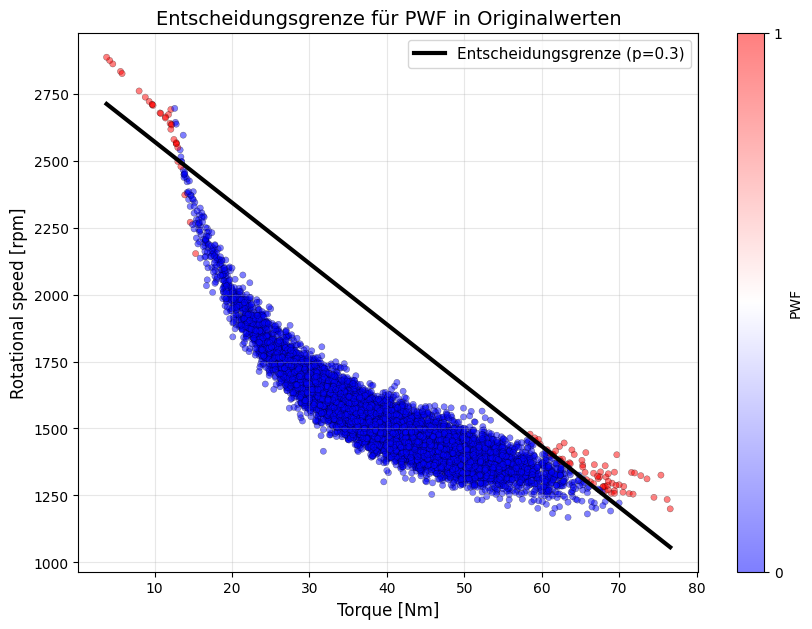


Interpretation:
  - Punkte OBEN der schwarzen Linie: Hohes PWF-Risiko (hohe Rotationsgeschwindigkeit)
  - Punkte UNTEN der schwarzen Linie: Geringes PWF-Risiko
  - Positive Koeffizienten (θ₁=5.59, θ₂=4.42):
    Höhere Torque ODER höhere Rotation erhöht PWF-Wahrscheinlichkeit


In [75]:
# Denormalisierung: Entscheidungsgrenze in Originalwerte zurückrechnen
# um aussagekräftige Schwellwerte für Torque und Rotational Speed zu geben

# Standardisierungsparameter
torque_mean = df['Torque [Nm]'].mean()
torque_std = df['Torque [Nm]'].std()
rotspeed_mean = df['Rotational speed [rpm]'].mean()
rotspeed_std = df['Rotational speed [rpm]'].std()

print('='*80)
print('INTERPRETIERBARE ENTSCHEIDUNGSGRENZE (Originalwerte)')
print('='*80)

print(f'\nStandardisierungsparameter:')
print(f'  Torque [Nm]:            mean={torque_mean:.2f}, std={torque_std:.2f}')
print(f'  Rotational speed [rpm]: mean={rotspeed_mean:.2f}, std={rotspeed_std:.2f}')

print(f'\nKoeffizienten im standardisierten Raum:')
print(f'  θ₀ (Intercept):  {theta_gd[0]:.6f}')
print(f'  θ₁ (Torque_z):   {theta_gd[1]:.6f}')
print(f'  θ₂ (RotSpeed_z): {theta_gd[2]:.6f}')

# Entscheidungsgrenze: p = best_thresh
# sigmoid(θ₀ + θ₁*Torque_z + θ₂*RotSpeed_z) = best_thresh
# Löse nach RotSpeed auf:
# RotSpeed_z = (1/θ₂) * [logit(best_thresh) - θ₀ - θ₁*Torque_z]

# logit(p) = log(p/(1-p))
logit_threshold = np.log(best_thresh / (1 - best_thresh))

# Kritische Torque/RotSpeed Kombinationen
print(f'\nKritische Kombinationen (PWF Wahrscheinlichkeit = {best_thresh:.2f}):')
print(f'  ("logit threshold" = {logit_threshold:.4f})')

# Beispiele: verschiedene Torque-Werte
torque_examples = [20, 30, 40, 50, 60]  # [Nm]

print(f'\nFür gegebene Torque-Werte → erforderliche RotSpeed um PWF-Grenze zu erreichen:')
print(f'  Torque [Nm] | RotSpeed [rpm]  | Interpretation')
print('-'*60)

for torque in torque_examples:
    # Standardisiere Torque
    torque_z = (torque - torque_mean) / torque_std
    # Löse nach RotSpeed_z auf
    rotspeed_z = (1.0 / theta_gd[2]) * (logit_threshold - theta_gd[0] - theta_gd[1] * torque_z)
    # Denormalisiere RotSpeed
    rotspeed = rotspeed_z * rotspeed_std + rotspeed_mean
    
    print(f'  {torque:6.1f}      | {rotspeed:10.1f}      | ', end='')
    if rotspeed < rotspeed_mean:
        print(f'Unter Durchschnitt ({rotspeed_mean:.0f})')
    elif rotspeed < rotspeed_mean + rotspeed_std:
        print(f'Im Durchschnitt')
    else:
        print(f'Über Durchschnitt')

# Grafik: Entscheidungsgrenze in Originalwerten
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

# Scatter der Datenpunkte in Originalwerten
sc = plt.scatter(df['Torque [Nm]'], df['Rotational speed [rpm]'], c=y, cmap='bwr', alpha=0.5, s=20, edgecolor='k', linewidth=0.3)

# Entscheidungsgrenze in Originalwerten plotten
torque_range = np.linspace(df['Torque [Nm]'].min(), df['Torque [Nm]'].max(), 100)
rotspeed_boundary = []

for t in torque_range:
    torque_z = (t - torque_mean) / torque_std
    rotspeed_z = (1.0 / theta_gd[2]) * (logit_threshold - theta_gd[0] - theta_gd[1] * torque_z)
    rotspeed = rotspeed_z * rotspeed_std + rotspeed_mean
    rotspeed_boundary.append(rotspeed)

plt.plot(torque_range, rotspeed_boundary, 'k-', linewidth=3, label=f'Entscheidungsgrenze (p={best_thresh})')

plt.xlabel('Torque [Nm]', fontsize=12)
plt.ylabel('Rotational speed [rpm]', fontsize=12)
plt.title(f'Entscheidungsgrenze für PWF in Originalwerten', fontsize=14)
plt.colorbar(sc, ticks=[0, 1], label='PWF')
plt.legend(fontsize=11)
plt.grid(alpha=0.3)
plt.show()

print(f'\nInterpretation:')
print(f'  - Punkte OBEN der schwarzen Linie: Hohes PWF-Risiko (hohe Rotationsgeschwindigkeit)')
print(f'  - Punkte UNTEN der schwarzen Linie: Geringes PWF-Risiko')
print(f'  - Positive Koeffizienten (θ₁={theta_gd[1]:.2f}, θ₂={theta_gd[2]:.2f}):')
print(f'    Höhere Torque ODER höhere Rotation erhöht PWF-Wahrscheinlichkeit')
